# Dalitz Plot Helpers

The `dalitz` library contains numerous Dalitz plot helper functions and two classes:
 - DalitzKinematics
 - DalitzPhaseSpace
both dedicated to calculate kinematic variables for a Dalitz plot decay.

## DalitzPhaseSpace

`DalitzPhaseSpace` class contains all is needed to deal with the kinematics of a Dalitz plot decay.
Once the object is initialised given the masses of the mother and daughter particles, a set of functions is provided to extrapolate the particles' momenta and squared Dalitz plot variables for each event in the phase space defined by $m^2_{12}$ and $m^2_{23}$.

A function is also given to generate events uniformly in the Dalitz plot and to check whether an event is inside the Dalitz plot.

The class is built upon `numpy` arrays for speed and portability.

In [2]:
import numpy as np
from analysis_helpers.dalitz import DalitzPhaseSpace

Let's consider the phase space for $D^0\to K^0_S\pi^+\pi^-$ decays. 
Since the phase space is defined on the $m^2_{12}$ and $m^2_{23}$ variables, we declare the object with `mA = mC = 0.13957` ($m(\pi)$) and `mB = 0.4976` ($m(K^0)$).

In [11]:
dps = DalitzPhaseSpace(0.13957, 0.4976, 0.13957, 1.86484)

For simplicity we generate a sample of 100k events.

In [12]:
sample = dps.uniform_sample(100000)

The invariant mass squared of each combination of particles can be accessed with the functions `m2xy` acting upon the sample. While `m2ab` and `m2bc` simply filter the array by the relevant column, `m2ac` uses the kinematic boundaries of the Dalitz to calculate the value.

In [13]:
m2ab = dps.m2ab(sample)
m2ac = dps.m2ac(sample)
m2bc = dps.m2bc(sample)

A function to draw the Dalitz plot is found in `plotting` library

/Users/maurizio/Documents/GitRepos/analysis_helpers/src/analysis_helpers/plotting.py:424: RuntimeWarning: invalid value encountered in sqrt
  Ymin = np.power(est2+est3,2) - np.power(np.sqrt(est2*est2-masses[2]*masses[2])+ np.sqrt(est3*est3-masses[3]*masses[3]),2)
/Users/maurizio/Documents/GitRepos/analysis_helpers/src/analysis_helpers/plotting.py:425: RuntimeWarning: invalid value encountered in sqrt
  Ymax = np.power(est2+est3,2) - np.power(np.sqrt(est2*est2-masses[2]*masses[2])- np.sqrt(est3*est3-masses[3]*masses[3]),2)


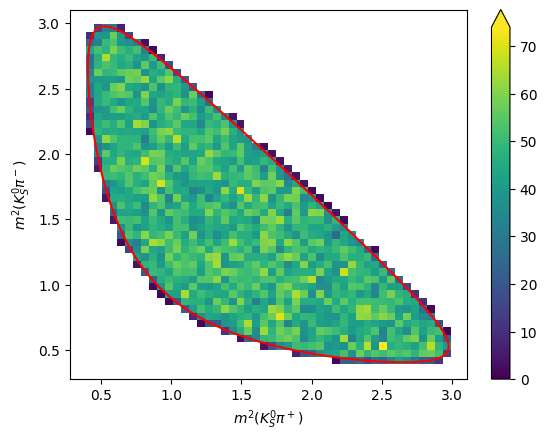

In [17]:
from analysis_helpers.plotting import plot_dalitz
fig, ax = plot_dalitz(m2ab, m2bc, xlab=r'$m^2(K^0_S\pi^+)$', ylab=r'$m^2(K^0_S\pi^-)$', bins=50, masses=[1.86484, 0.13957, 0.4976, 0.13957],  boundary=True)

In [9]:
sample

array([], shape=(0, 2), dtype=float64)